In [2]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 32.5 MB/s eta 0:00:00


In [3]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# Zmienne wejściowe

In [4]:
obs = ctrl.Antecedent(np.arange(0, 11, 1), 'obsluga') # zmienn wejściowa
smak = ctrl.Antecedent(np.arange(0, 11, 1), 'smak')
wartosc = ctrl.Antecedent(np.arange(0, 301, 1), 'wartosc')

# Zmienna wyjściowa

In [5]:
napiwek = ctrl.Consequent(np.arange(0, 51, 1), 'napiwek') # zmienna wyjściowa , domyślnie stosowana metoda defuzyfikacji

# Funkcje przynależności

##1) obsługa

In [8]:
obs['zla'] = fuzz.trimf(obs.universe, [0, 0, 5])   # trójkątna funkcja przynależności
obs['srednia'] = fuzz.trimf(obs.universe, [2, 5, 8])
obs['dobra'] = fuzz.trimf(obs.universe, [5, 10, 10])


#2) smak

In [9]:
# Funkcje przynależności - Smak
smak['zly'] = fuzz.trimf(smak.universe, [0, 0, 5])
smak['sredni'] = fuzz.trimf(smak.universe, [2, 5, 8])
smak['dobry'] = fuzz.trimf(smak.universe, [5, 10, 10])

# 3) wartość zamówienia  

In [10]:
# Funkcje przynależności - Wartość zamówienia
wartosc['niska'] = fuzz.trimf(wartosc.universe, [0, 0, 150])
wartosc['srednia'] = fuzz.trimf(wartosc.universe, [50, 150, 250])
wartosc['wysoka'] = fuzz.trimf(wartosc.universe, [150, 300, 300])

#4) napiwek

In [11]:
# Funkcje przynależności - Napiwek
napiwek['maly'] = fuzz.trimf(napiwek.universe, [0, 0, 20])
napiwek['sredni'] = fuzz.trimf(napiwek.universe, [10, 25, 40])
napiwek['duzy'] = fuzz.trimf(napiwek.universe, [30, 50, 50])

# Tworzenie Bazy reguł

In [13]:
# Baza Reguł
rules = []
levels = ['zla', 'srednia', 'dobra'] # obsługa
smak_levels = ['zly', 'sredni', 'dobry'] # smak
wartosc_levels = ['niska', 'srednia', 'wysoka'] # wartosc zamowienia

In [14]:
# 27 reguł
for o in levels:
    for s in smak_levels:
        for w in wartosc_levels:
            # Zapisujemy priorytety w bardziej szczegółowy sposób
            if o == 'dobra' and s == 'dobry' and w == 'wysoka':
                tip = 'duzy'
            elif o == 'dobra' and s == 'dobry':
                tip = 'duzy'
            elif o == 'srednia' and s == 'sredni' and w != 'niska':
                tip = 'sredni'
            elif o == 'dobra' and (s == 'sredni' or w == 'wysoka'):
                tip = 'sredni'
            elif o == 'srednia' and s == 'dobry':
                tip = 'sredni'
            elif o == 'zla' or s == 'zly':
                tip = 'maly'
            else:
                tip = 'maly'


            # regula logiczna (fuzzy rule) np. Jeśli obsługa jest średnia I smak jest dobry I wartość jest wysoka, to napiwek jest duży.
            rules.append(ctrl.Rule(obs[o] & smak[s] & wartosc[w], napiwek[tip])) # WARUNEK -kombinacja zmiennych wejściowych, WNIOSEK - wynik

In [15]:
# System fuzzy na bazie reguł
napiwek_ctrl = ctrl.ControlSystem(rules)
# tworzymy symulację czyli możliwość podania danych wejściowych i otrzymania wyniku
napiwek_sim = ctrl.ControlSystemSimulation(napiwek_ctrl)

In [16]:
# Przykład działania (podajemy dane wejściowe)
napiwek_sim.input['obsluga'] = 7
napiwek_sim.input['smak'] = 6
napiwek_sim.input['wartosc'] = 120

In [17]:
# proces rozmytego wnioskowania
napiwek_sim.compute()
print(f"Wysokość napiwku: {napiwek_sim.output['napiwek']:.2f} PLN")  # wartosc napiwku z zlotowkach to wynik output

Wysokość napiwku: 25.00 PLN


# Wizualizacja - mapa 3D

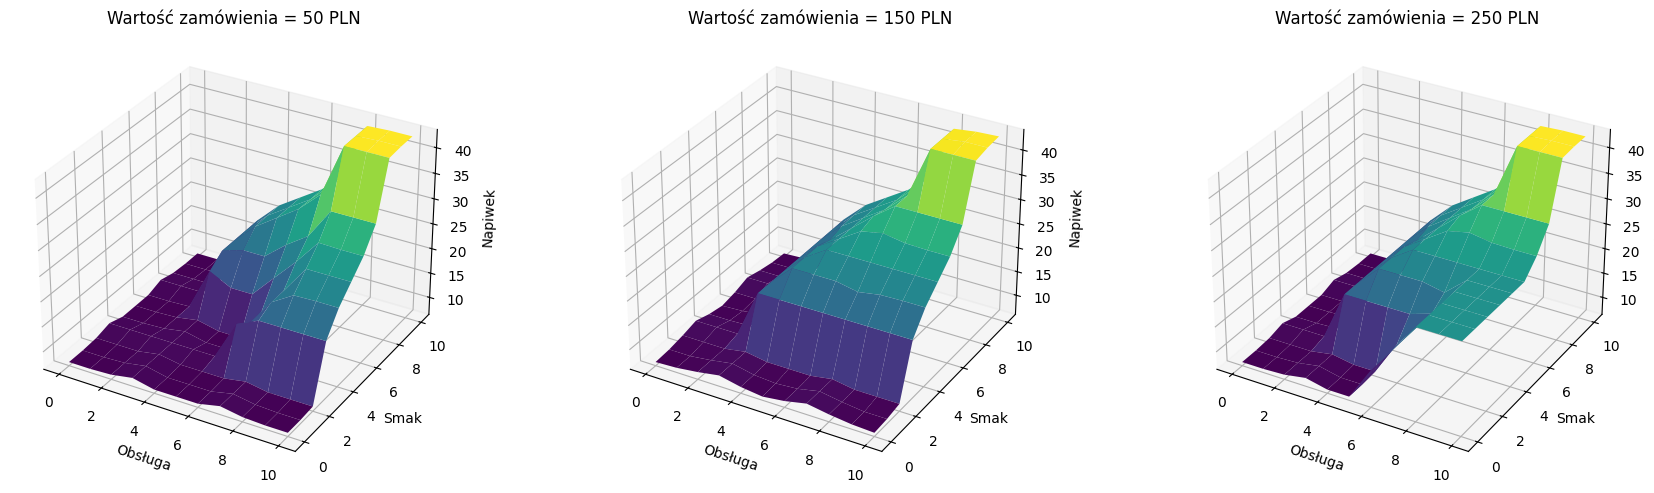

In [22]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0, 11, 1)
y = np.arange(0, 11, 1)
X, Y = np.meshgrid(x, y)

# Tworzymy wykresy w jednej figurze
fig = plt.figure(figsize=(18, 5))

# Różne wartości trzeciej zmiennej
wartosci = [50, 150, 250]

for idx, wartosc_val in enumerate(wartosci):
    Z = np.zeros_like(X, dtype=float)

    for i in range(len(x)):
        for j in range(len(y)):
            napiwek_sim.input['obsluga'] = x[i]
            napiwek_sim.input['smak'] = y[j]
            napiwek_sim.input['wartosc'] = wartosc_val
            napiwek_sim.compute()
            Z[j, i] = napiwek_sim.output['napiwek']

    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis')
    ax.set_title(f'Wartość zamówienia = {wartosc_val} PLN')
    ax.set_xlabel('Obsługa')
    ax.set_ylabel('Smak')
    ax.set_zlabel('Napiwek')

plt.tight_layout()
plt.show()



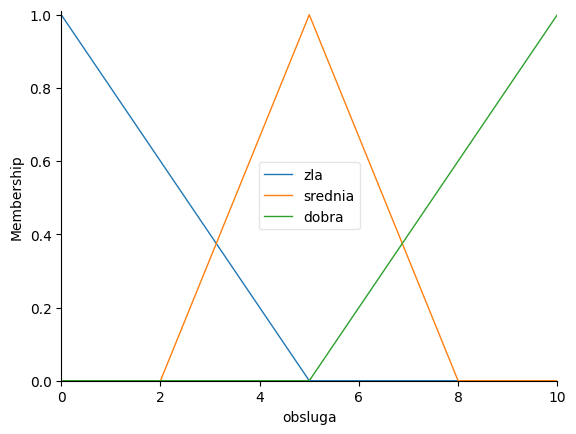

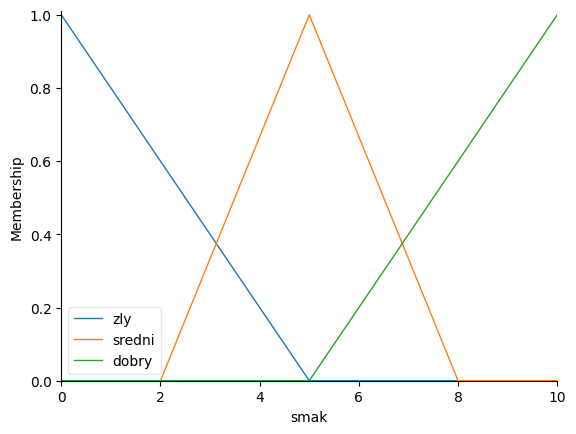

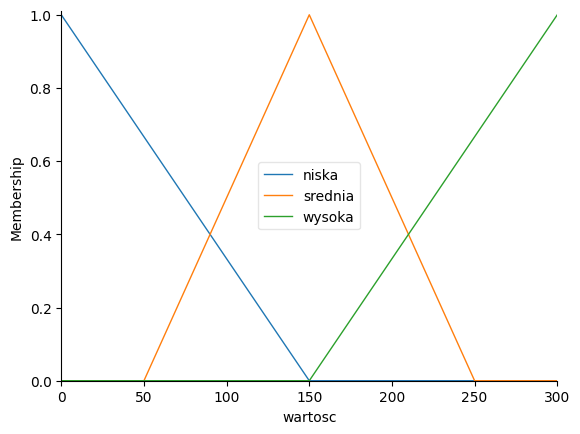

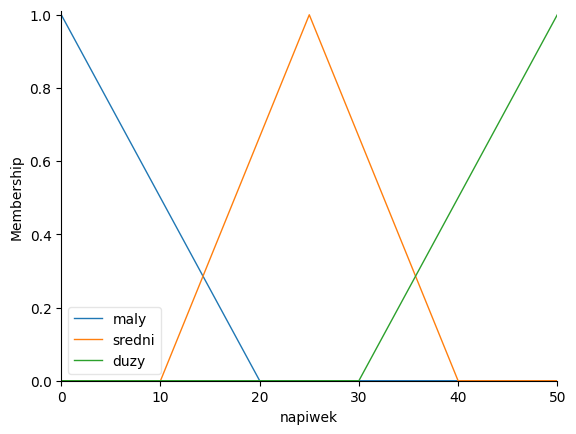

In [19]:
# WIZUALIZACJA FUNKCJI PRZYNALEŻNOŚCI
obs.view()
smak.view()
wartosc.view()
napiwek.view()
plt.show()

# Podsumowanie i wnioski

- W przedstawionym projekcie zbudowano rozmyty system decyzyjny służący do określania wysokości napiwku na podstawie trzech zmiennych wejściowych: obsługi, smaku potrawy oraz wartości zamówienia. Dla każdej zmiennej zdefiniowano intuicyjne funkcje przynależności (trójkątne), a całość oparto na 27 regułach językowych opisujących różne scenariusze obsługi klienta.

  System ten został przetestowany dla różnych kombinacji wejść, a także wizualnie przeanalizowany przy pomocy wykresów przestrzennych (3D). Szczególnie cenne okazały się przekroje napiwku w zależności od poziomu obsługi i smaku, przy stałych wartościach zamówienia – pozwoliły one zauważyć, jak zmiana jednej zmiennej wpływa na wynik końcowy.

  Dzięki metodzie wnioskowania rozmytego (z domyślną deffuzyfikacją centroid) system podejmuje decyzje w sposób zbliżony do ludzkiego rozumowania: uwzględnia nie tylko skrajne przypadki, ale i wartości pośrednie, zapewniając płynne przejścia między poziomami napiwków.

- 🔍 Wnioski końcowe:

  System poprawnie odwzorowuje zależność napiwku od jakości obsługi, smaku i wartości zamówienia.

 Dobrze dobrane funkcje przynależności i reguły umożliwiają realistyczne odwzorowanie zachowań klienta.

 Przekroje 3D pokazują, że napiwek wzrasta wraz z poprawą obsługi i smaku, zwłaszcza przy wysokiej wartości zamówienia.

 System może być rozszerzony o dodatkowe czynniki (np. czas oczekiwania, nastrój klienta), co uczyniłoby go jeszcze bardziej precyzyjnym.